In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [2]:
ruta = os.path.join("..", 'Data', 'TouristAccommodationClean02022026.csv')
df = pd.read_csv(ruta)
df.head()
df.info()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   apartment_id                 10000 non-null  int64  
 1   name                         9997 non-null   object 
 2   description                  9862 non-null   object 
 3   host_id                      10000 non-null  int64  
 4   neighbourhood_name           10000 non-null  object 
 5   neighbourhood_district       6079 non-null   object 
 6   room_type                    10000 non-null  object 
 7   accommodates                 10000 non-null  int64  
 8   bathrooms                    10000 non-null  float64
 9   bedrooms                     10000 non-null  int64  
 10  beds                         10000 non-null  int64  
 11  amenities_list               9983 non-null   object 
 12  price                        10000 non-null  float64
 13  minimum_nights   

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'country', 'city', 'insert_date', 'unique_id', 'city_neighbourhood',
       'ocupacion_30'],
      dtype='object')

*Filtrar precios válidos(positivos) y ver tipos de habitación*

In [3]:
df = df[df['price'] > 0]
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Hotel room', 'Shared room'],
      dtype=object)

*Eliminar filas con valores nulos en columnas claves*

In [4]:
df = df.dropna(subset=['price', 'review_scores_rating', 'room_type', 'city']).copy()

*Normalizar la columna rating*

*Analisis descriptivos*

In [5]:
# Normalizar review score (0–1000 → 0–10)
df['review_scores_rating'] = df['review_scores_rating'] / 100

# Comprobar escala
df[['price', 'review_scores_rating']].describe().round(2)


,price,review_scores_rating
count,7291.00,7291.00
mean,936.07,9.19
std,839.79,0.92
min,80.00,2.00
25%,450.00,8.90
50%,700.00,9.40
75%,1130.00,9.80
max,25857.00,10.00


*Analisis descriptivo por type_room*

In [6]:
df_room = (df.groupby("room_type").agg(price_mediana=("price", "median"),price_promedio=("price", "mean"),rating_mediana=("review_scores_rating", "median"),
          rating_promedio=("review_scores_rating", "mean"),count=("price", "count")).reset_index().round(2))
df_room

,room_type,price_mediana,price_promedio,rating_mediana,rating_promedio,count
0,Entire home/apt,900.0,1156.85,9.4,9.20,5028
1,Hotel room,990.0,1068.64,9.5,9.26,59
2,Private room,350.0,430.57,9.4,9.19,2156
3,Shared room,235.0,351.15,9.1,8.93,48


*Visualizar la distribucion de precio por tipo de habitación*

showfliers:Oculta los outliers visualmente, pero NO los elimina del dataframe.

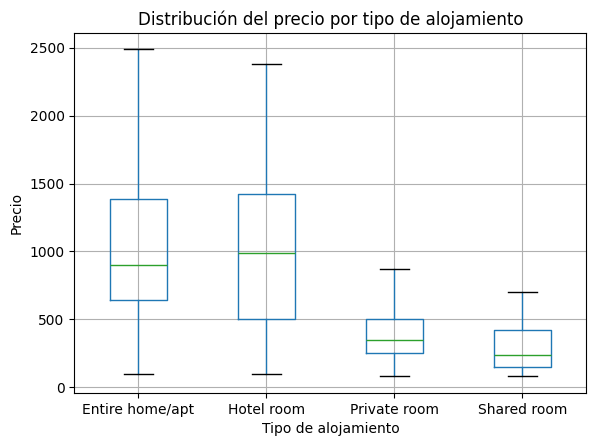

In [7]:
df.boxplot(column="price", by="room_type", showfliers=False)
plt.title("Distribución del precio por tipo de alojamiento")
plt.suptitle("")
plt.xlabel("Tipo de alojamiento")
plt.ylabel("Precio")
plt.show()


*Relación precio-satisfacción*

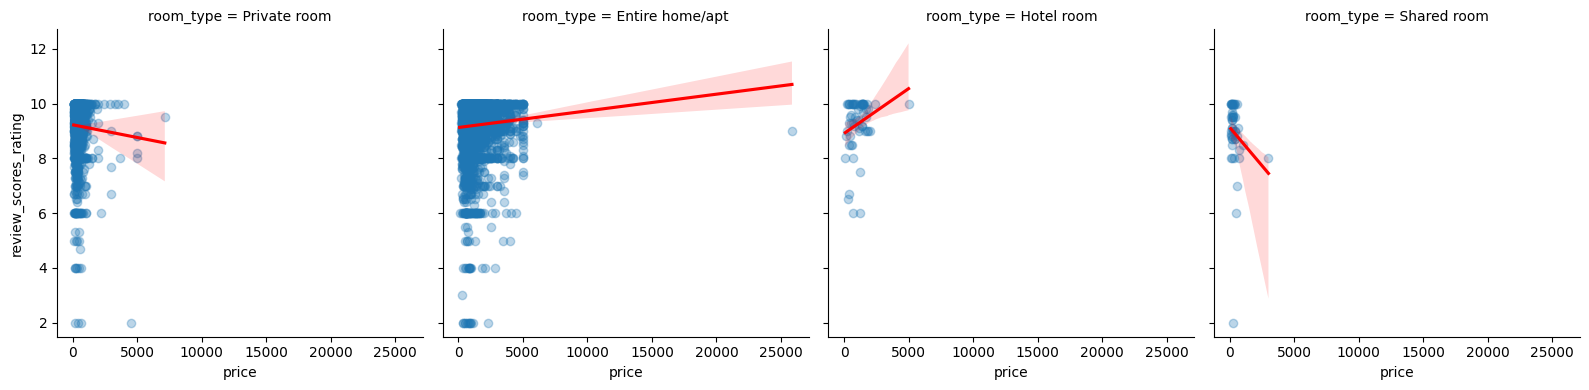

In [8]:
sns.lmplot(data=df,x="price",y="review_scores_rating",col="room_type",height=4,
    aspect=1,scatter_kws={"alpha": 0.3},line_kws={"color": "red"})
plt.show()

*Satisfacción promedio por ciudad y tipo de habitación*

<Axes: xlabel='room_type', ylabel='city'>

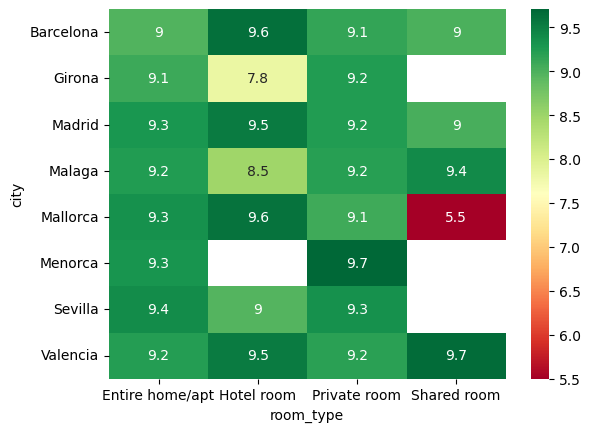

In [9]:
heatmap_data = (df.groupby(['city','room_type'])['review_scores_rating'].mean().reset_index()
    .pivot(index='city', columns='room_type', values='review_scores_rating'))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn')


*analisis de correlación*

In [10]:
for rt in df['room_type'].unique():
    sub = df[df['room_type'] == rt]
    corr = sub['price'].corr(sub['review_scores_rating'], method='pearson')
    n = len(sub)
    print(f"{rt}: correlación={corr:.2f} | n={n}")


Private room: correlación=-0.04 | n=2156
Entire home/apt: correlación=0.06 | n=5028
Hotel room: correlación=0.25 | n=59
Shared room: correlación=-0.18 | n=48


- **Private room (-0.04)** correlación practicamente nula, el precio no influye en la satisfacción.
- **Entire home/apt ( 0.06)** relación débil positiva. El precio no es lo más importante en la satisfacción.
- **Hotel room (0.24)** relación positiva moderada un pago alto puede transmitir mejor experiencia.
- **Shared room (-0.19)** relación negativa, a mayor precio menor satisfacción.

In [11]:
for rt, sub in df.groupby('room_type'):
    corr = sub['price'].corr(sub['review_scores_rating'], method='spearman')
    print(f"{rt:<15} | Spearman={corr:.2f} | n={len(sub)}")


Entire home/apt | Spearman=0.13 | n=5028
Hotel room      | Spearman=0.26 | n=59
Private room    | Spearman=0.06 | n=2156
Shared room     | Spearman=-0.31 | n=48


- **Entire home/apt (0.13)** correlación positiva débil, mejor rating si es ligeramente más caro.
- **Hotel room      (0.22)** correlación positiva moderada.pero la muestra es muy pequeña.
- **Private room    (0.06)** correlación casi nula entre precio y satisfacción.
- **Shared room     (-0.34)** correlación negativa moderada


Modelo OLS para Private room:
                              OLS Regression Results                             
Dep. Variable:     review_scores_rating   R-squared:                       0.000
Model:                              OLS   Adj. R-squared:                 -0.000
Method:                   Least Squares   F-statistic:                    0.5671
Date:                  Thu, 05 Feb 2026   Prob (F-statistic):              0.451
Time:                          23:41:31   Log-Likelihood:                -2861.5
No. Observations:                  2156   AIC:                             5727.
Df Residuals:                      2154   BIC:                             5738.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


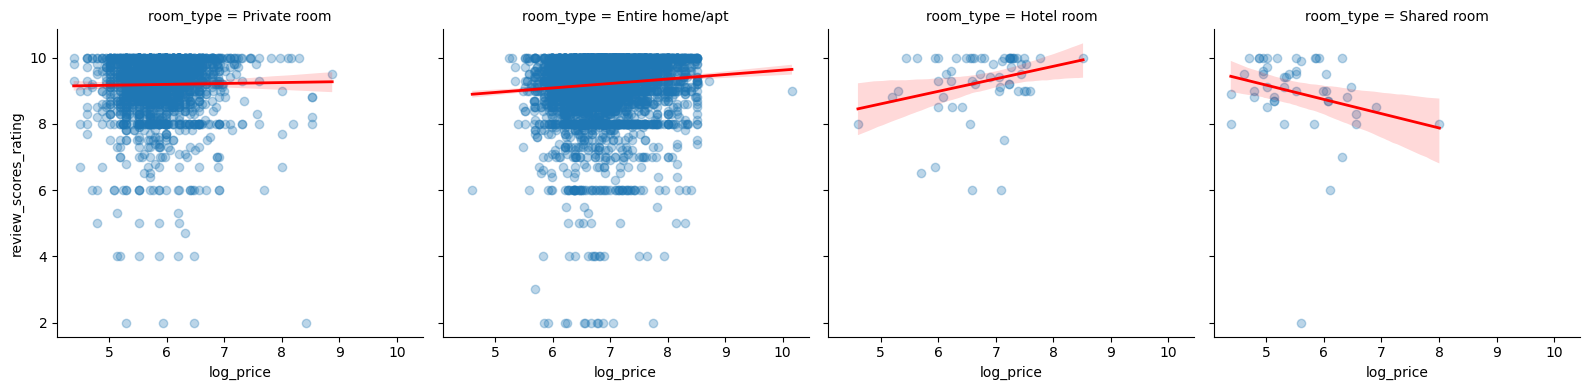

In [12]:
# columna logaritmica del precio
df['log_price'] = np.log(df['price'])

# Ajustar modelo OLS por tipo de habitación
for room in df['room_type'].unique():
    sub = df[df['room_type'] == room]
    model = smf.ols("review_scores_rating ~ log_price", data=sub).fit()
    print(f"\nModelo OLS para {room}:\n", model.summary())

# Gráfico log_price vs review_scores_rating por room_type
sns.lmplot(
    data=df,
    x="log_price",
    y="review_scores_rating",
    col="room_type",
    height=4,
    aspect=1,
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2, "color": "red"}
)

plt.show()

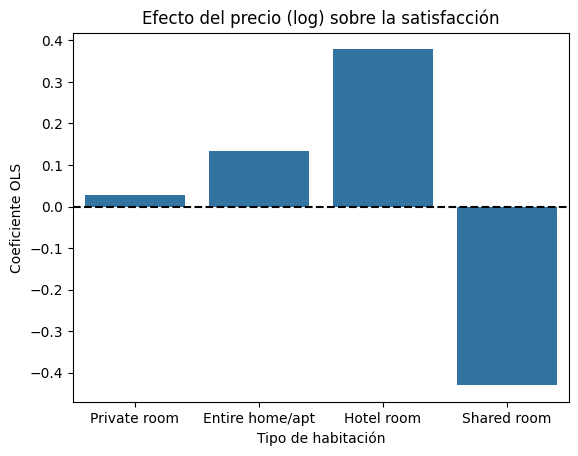

In [13]:
results = []

for room in df['room_type'].unique():
    sub = df[df['room_type'] == room]
    model = smf.ols("review_scores_rating ~ log_price", data=sub).fit()
    
    results.append({
        "room_type": room,
        "coef_log_price": model.params["log_price"],
        "p_value": model.pvalues["log_price"]
    })

coef_df = pd.DataFrame(results)

sns.barplot(
    data=coef_df,
    x="room_type",
    y="coef_log_price"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Efecto del precio (log) sobre la satisfacción")
plt.ylabel("Coeficiente OLS")
plt.xlabel("Tipo de habitación")
plt.show()


**modelo multivariante aditivo**

*incorporando tanto el precio logarítmico como el tipo de habitación como variable categórica*

In [14]:
# Modelo OLS simplificado: review_scores_rating ~ log_price + room_type
model_simple = smf.ols(
    formula="review_scores_rating ~ log_price + C(room_type)",
    data=df
).fit()

# 4️⃣ Mostrar resumen del modelo
print(model_simple.summary())

                             OLS Regression Results                             
Dep. Variable:     review_scores_rating   R-squared:                       0.005
Model:                              OLS   Adj. R-squared:                  0.004
Method:                   Least Squares   F-statistic:                     8.770
Date:                  Thu, 05 Feb 2026   Prob (F-statistic):           4.64e-07
Time:                          23:41:34   Log-Likelihood:                -9740.9
No. Observations:                  7291   AIC:                         1.949e+04
Df Residuals:                      7286   BIC:                         1.953e+04
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

**Entire home/apt es la categoría de referencia**

In [15]:
city_stats = (
    df.dropna(subset=['city', 'review_scores_rating'])
      .groupby('city')['review_scores_rating']
      .agg(['mean','median','count'])
      .round(2)
      .sort_values('mean', ascending=False)
)

print(city_stats)

           mean  median  count
city                          
Sevilla    9.36     9.5    454
Menorca    9.34     9.6    149
Mallorca   9.30     9.6   1010
Madrid     9.27     9.5   1702
Malaga     9.22     9.4    430
Valencia   9.22     9.4    441
Girona     9.10     9.4    938
Barcelona  9.07     9.3   2167


C:\Users\avril\AppData\Local\Temp\ipykernel_44168\1184895986.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


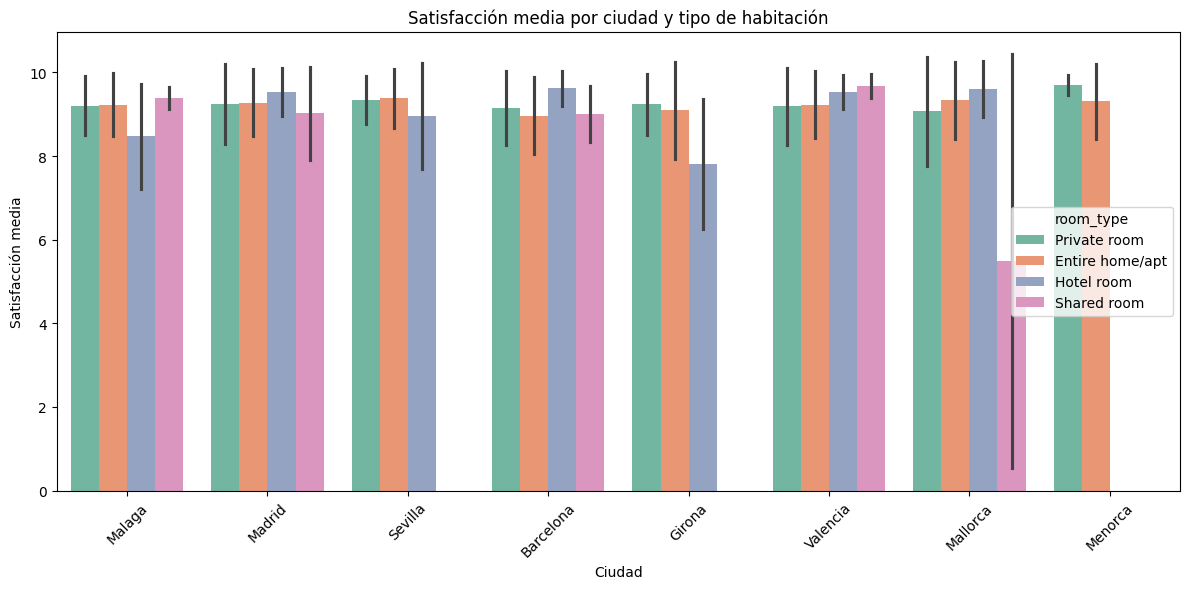

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='city',
    y='review_scores_rating',
    hue='room_type',
    ci='sd',   # muestra desviación estándar
    palette='Set2'
)

plt.title('Satisfacción media por ciudad y tipo de habitación')
plt.xlabel('Ciudad')
plt.ylabel('Satisfacción media')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Modelo completo precio+ tipo de habitación + ciudad*

In [17]:
df_model = (df.dropna(subset=['price', 'review_scores_rating', 'room_type', 'city']).copy())
df_model['log_price'] = np.log(df_model['price'])
model_city = smf.ols("review_scores_rating ~ log_price + C(room_type) + C(city)",data=df_model).fit()
print(model_city.summary())


                             OLS Regression Results                             
Dep. Variable:     review_scores_rating   R-squared:                       0.019
Model:                              OLS   Adj. R-squared:                  0.018
Method:                   Least Squares   F-statistic:                     13.10
Date:                  Thu, 05 Feb 2026   Prob (F-statistic):           4.47e-25
Time:                          23:41:35   Log-Likelihood:                -9686.9
No. Observations:                  7291   AIC:                         1.940e+04
Df Residuals:                      7279   BIC:                         1.948e+04
Df Model:                            11                                         
Covariance Type:              nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

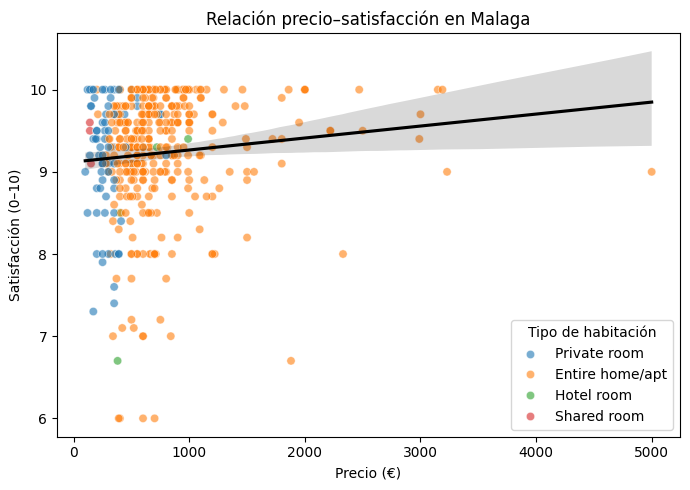

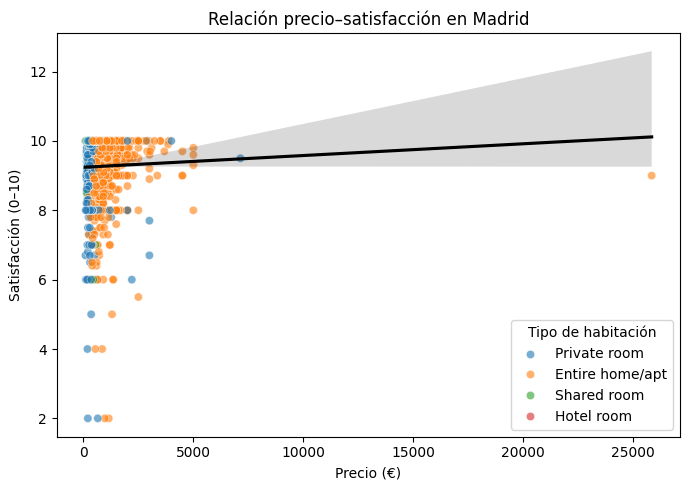

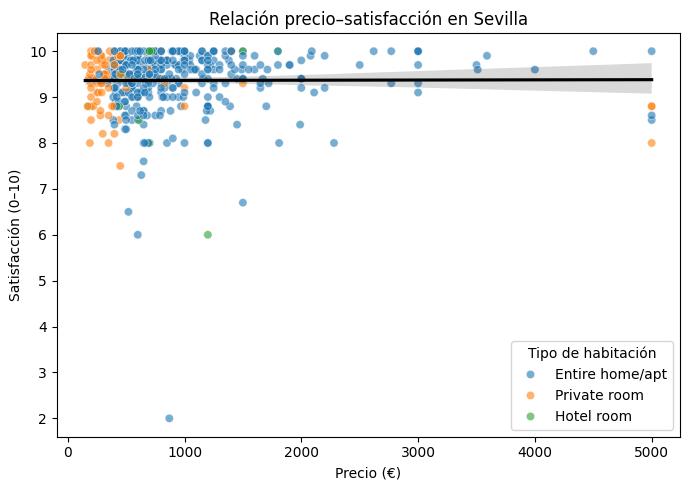

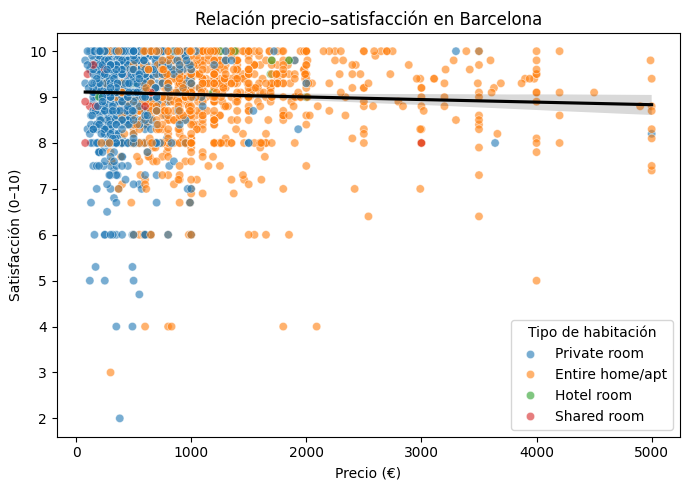

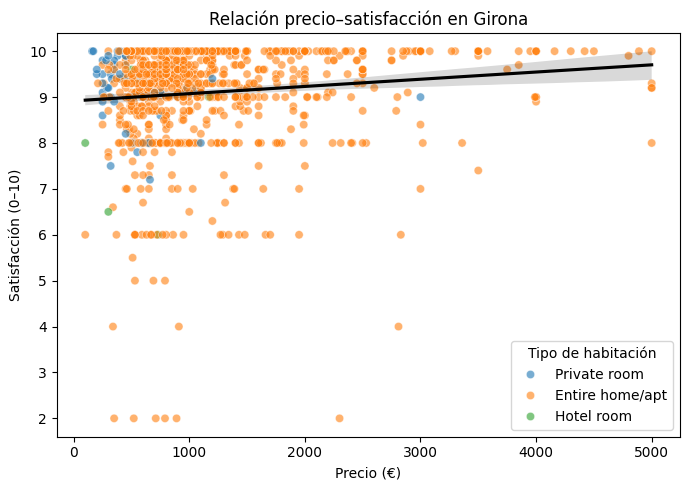

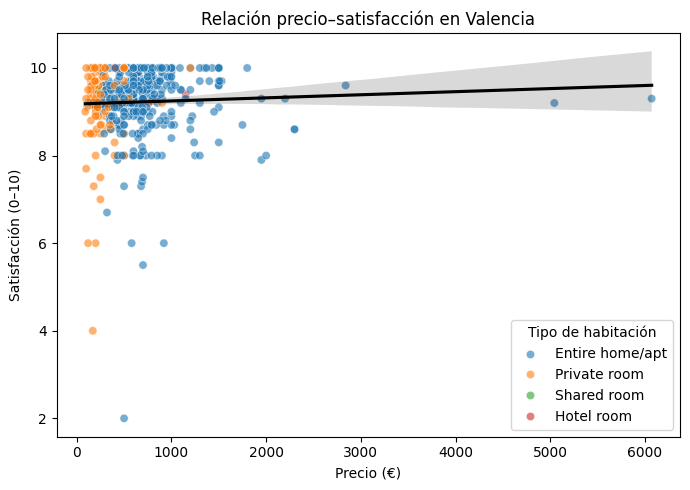

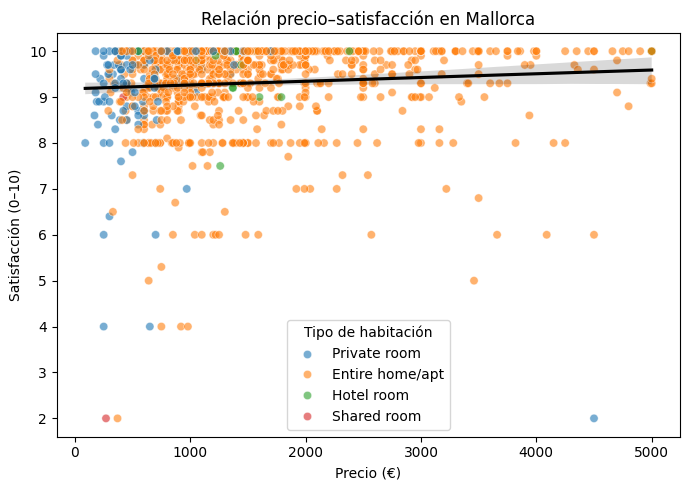

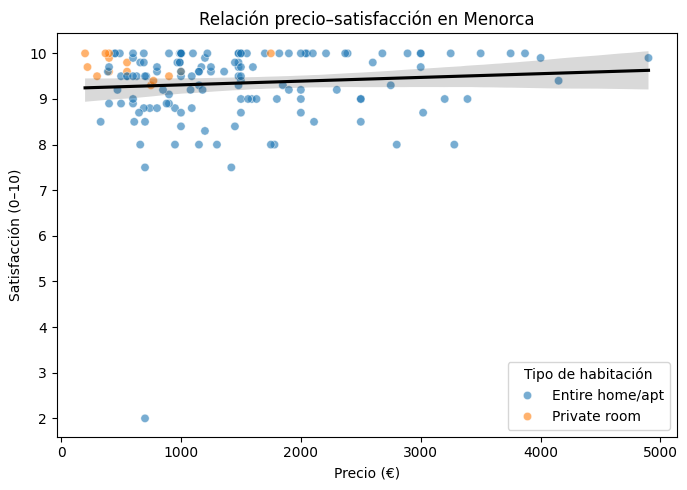

In [18]:
ciudades = df['city'].unique()

for c in ciudades:
    sub = df[df['city'] == c]

    plt.figure(figsize=(7,5))
    sns.scatterplot(
        data=sub,
        x='price',
        y='review_scores_rating',
        hue='room_type',
        alpha=0.6
    )

    sns.regplot(
        data=sub,
        x='price',
        y='review_scores_rating',
        scatter=False,
        color='black'
    )

    plt.title(f"Relación precio–satisfacción en {c}")
    plt.xlabel("Precio (€)")
    plt.ylabel("Satisfacción (0–10)")
    plt.legend(title="Tipo de habitación")
    plt.tight_layout()
    plt.show()